###
### PROBLEM 5: Parameter Sweep on Decision Trees

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import itertools
from sklearn.tree import DecisionTreeClassifier, export_text

In [10]:
# --------------------  Reading Data -------------
mushroom_df = pd.read_csv("mushrooms.csv")

In [4]:
mushroom_df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
# ----- Encoding Categorical Features -------------

le = LabelEncoder()
for col in mushroom_df.columns:
    mushroom_df[col] = le.fit_transform(mushroom_df[col])

In [12]:
# ----- Split into features and target ----------

X = mushroom_df.drop('class', axis=1)
y = mushroom_df['class']

In [13]:
# ----- Train-test split ----------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [14]:
# ----------- Defining Function -------------

def tree_sweep(train, test, 
               size=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
               purity=[60, 65, 70, 75, 80, 85, 90, 95]
               ):

    X_train, y_train = train
    X_test, y_test = test

    results = []

    for sz, pur in itertools.product(size, purity):
        # Calculate min_samples_split from size percentage
        min_samples_split = max(2, int(len(X_train) * (sz / 100.0)))

        # Build and train the decision tree using 'entropy'
        clf = DecisionTreeClassifier(criterion='entropy', min_samples_split=min_samples_split, random_state=42)
        clf.fit(X_train, y_train)

        # Compute accuracy
        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        # Append results
        results.append([sz, pur, round(train_acc, 4), round(test_acc, 4)])

    # Save results to CSV
    sweep_df = pd.DataFrame(results, columns=["size", "purity", "train_accuracy", "test_accuracy"])
    sweep_df.to_csv('tree_sweep.csv', index=False)
    
    return sweep_df

In [15]:
# ------ Parameter Sweep ----------------

sweep_df = tree_sweep((X_train, y_train), (X_test, y_test))

In [17]:
sweep_df

,size,purity,train_accuracy,test_accuracy
0,10,60,0.9567,0.9582
1,10,65,0.9567,0.9582
2,10,70,0.9567,0.9582
3,10,75,0.9567,0.9582
4,10,80,0.9567,0.9582
...,...,...,...,...
75,100,75,0.7286,0.7354
76,100,80,0.7286,0.7354
77,100,85,0.7286,0.7354
78,100,90,0.7286,0.7354


####
#### Finding the Most Optimal Tree

In [18]:
# Find the best row with highest test accuracy
best_row = sweep_df.loc[sweep_df['test_accuracy'].idxmax()]

# Extract best parameters
best_size = best_row['size']
best_purity = best_row['purity']
print("Best Size:", best_size, "Best Purity:", best_purity)

Best Size: 10.0 Best Purity: 60.0


####
#### Train Optimal Trees and generate Rules

In [20]:
# Calculate min_samples_split from best size
min_samples_split_best = max(2, int(len(X_train) * (best_size / 100.0)))

# Train decision tree with best settings
best_tree = DecisionTreeClassifier(criterion='entropy', min_samples_split=min_samples_split_best, random_state=42)
best_tree.fit(X_train, y_train)

# Generate textual rules
rules_text = export_text(best_tree, feature_names=list(X_train.columns))
print(rules_text)

|--- gill-color <= 0.50
|   |--- class: 1
|--- gill-color >  0.50
|   |--- spore-print-color <= 1.50
|   |   |--- stalk-root <= 0.50
|   |   |   |--- class: 0
|   |   |--- stalk-root >  0.50
|   |   |   |--- class: 1
|   |--- spore-print-color >  1.50
|   |   |--- gill-size <= 0.50
|   |   |   |--- spore-print-color <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- spore-print-color >  4.50
|   |   |   |   |--- class: 0
|   |   |--- gill-size >  0.50
|   |   |   |--- class: 1



####
#### Interpretation of above tree:
- Root Node: If gill-color is less than or eqaul to 0.50 then classify with class 1
- Else go to alternate branch
- If gill-color > 0.50 then check spore-print-color
    - If spore-print-color <= 1.50 and stalk-root <= 0.50 then classify with class 0
    - If spore-print-color <= 1.50 and stalk-root > 0.50 then classify with class 1
- Else continue further in the branch
- If gill-color > 0.50 and spore-print-color > 1.50 then check gill-size
    - If gill-size <= 0.50 then check spore-print-color
        - spore-print-color <= 4.50 then classify as class 0
        - spore-print-color > 4.50 then classify as class 0
    - If gill-size > 0.50 then classify as class 1

####
#### Plot Purity vs Accuracy for Optimal Size

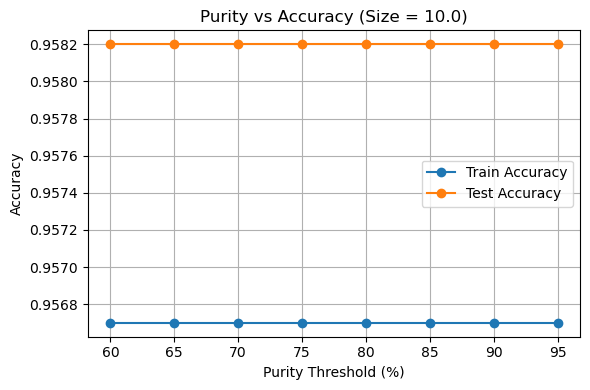

In [25]:
# Filter sweep_df for rows with the best size
purity_plot_df = sweep_df[sweep_df['size'] == best_size]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(purity_plot_df['purity'], purity_plot_df['train_accuracy'], label='Train Accuracy', marker='o')
plt.plot(purity_plot_df['purity'], purity_plot_df['test_accuracy'], label='Test Accuracy', marker='o')
plt.title(f'Purity vs Accuracy (Size = {best_size})')
plt.xlabel('Purity Threshold (%)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####
#### Interpretation:
- As the Purity Threshold increases, the accuracy remains same for both Training and Test Data for size = 10
- Very close Training and Test Accuracy inidcates good generalised model.

####
#### Plot Size vs Accuracy for Optimal Purity

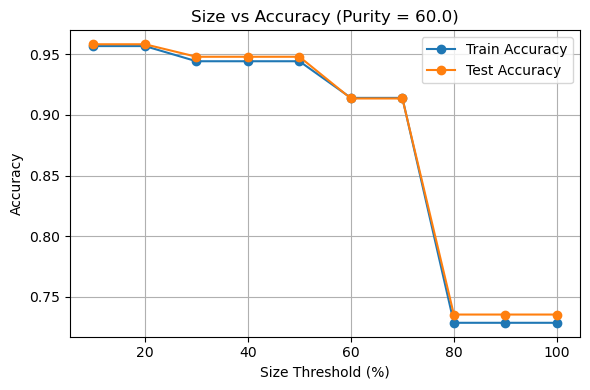

In [24]:
# Filter sweep_df for rows with the best purity
size_plot_df = sweep_df[sweep_df['purity'] == best_purity]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(size_plot_df['size'], size_plot_df['train_accuracy'], label='Train Accuracy', marker='o')
plt.plot(size_plot_df['size'], size_plot_df['test_accuracy'], label='Test Accuracy', marker='o')
plt.title(f'Size vs Accuracy (Purity = {best_purity})')
plt.xlabel('Size Threshold (%)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####
#### Interpretation:
- The variance between Training and Test Accuracy is very low.
- As the Size increases, Accuracy drops.
- Accuracy drops drastically for size greater than 70
- Curve is flat between 30 to 50 which indicates an optimal window.